In [11]:
import pandas as pd
import glob
import os
from tqdm import tqdm 
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from scipy import stats
import time
import json

In [13]:
def create_taml_meta_tasks_newscold_correct_ratio(balanced_df, metadata_path='articles_metadata.csv',
                                                 embeddings_path='articles_embeddings.pickle',
                                                 output_dir='taml_meta_newscold_correct',
                                                 cold_threshold_hours=3,
                                                 n_time_periods=8,
                                                 support_size=64,
                                                 query_size=64,
                                                 min_samples_per_task=128,
                                                 hot_to_cold_ratio=2.0,
                                                 max_cold_samples=1000,  # Максимум холодных для использования
                                                 random_state=42):
    """
    Создание мета-задач TAML с правильным отношением:
    - Холодные: максимум max_cold_samples (например 1000)
    - Горячие: максимум hot_to_cold_ratio × используемые_холодные
    """
    print("=" * 80)
    print("СОЗДАНИЕ МЕТА-ЗАДАЧ TAML (ПРАВИЛЬНОЕ ОТНОШЕНИЕ)")
    print("=" * 80)
    
    total_start = time.time()
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(f"{output_dir}/tasks", exist_ok=True)
    
    np.random.seed(random_state)
    
    # 1. Загрузка данных
    print("\n[1/5] Загрузка данных...")
    df = balanced_df.copy()
    
    with open(embeddings_path, 'rb') as f:
        embeddings_matrix = pickle.load(f)
    
    metadata = pd.read_csv(metadata_path)
    news_creation_time = dict(zip(metadata['article_id'], metadata['created_at_ts']))
    
    # 2. Подготовка категорий
    print("\n[2/5] Подготовка категорий...")
    
    df['click_datetime'] = pd.to_datetime(df['click_timestamp'], unit='ms')
    df['click_hour'] = df['click_datetime'].dt.hour
    df['time_period'] = (df['click_hour'] // (24 // n_time_periods)).astype(int)
    
    df['news_age_hours'] = (df['click_timestamp'] - df['click_article_id'].map(news_creation_time)) / (1000 * 3600)
    df['news_age_hours'] = df['news_age_hours'].fillna(24)
    df['news_group'] = np.where(df['news_age_hours'] <= cold_threshold_hours, 'cold', 'hot')
    
    print(f"✓ Холодные: {(df['news_group'] == 'cold').sum():,}")
    print(f"✓ Горячие: {(df['news_group'] == 'hot').sum():,}")
    
    # 3. Сначала обрабатываем ХОЛОДНЫЕ и запоминаем сколько использовали
    print("\n[3/5] Обработка ХОЛОДНЫХ новостей...")
    
    cold_data_used = {}  # {time_period: сколько семплов использовали}
    cold_tasks_info = {}  # {time_period: список задач}
    
    def get_embeddings_fast(news_ids):
        valid_ids = [int(nid) % embeddings_matrix.shape[0] for nid in news_ids]
        return embeddings_matrix[valid_ids]
    
    samples_per_task = support_size + query_size
    meta_tasks = []
    tasks_created = 0
    
    # ПЕРВЫЙ ПРОХОД: только холодные
    for time_period in range(n_time_periods):
        category_id = f"period{time_period}_cold"
        
        category_mask = (df['time_period'] == time_period) & (df['news_group'] == 'cold')
        category_data = df[category_mask].copy()
        category_size = len(category_data)
        
        print(f"  {category_id}: {category_size:,} семплов", end="")
        
        if category_size < min_samples_per_task:
            print(" → пропускаем (мало данных)")
            cold_data_used[time_period] = 0
            cold_tasks_info[time_period] = []
            continue
        
        # Ограничиваем холодные максимумом
        samples_to_use = min(category_size, max_cold_samples)
        
        if category_size > samples_to_use:
            working_indices = np.random.choice(
                category_data.index,
                size=samples_to_use,
                replace=False
            )
            working_data = df.loc[working_indices].copy()
            print(f" → используем {samples_to_use:,} из {category_size:,}")
        else:
            working_data = category_data.copy()
            print(f" → используем все {category_size:,}")
        
        # Сохраняем сколько использовали
        cold_data_used[time_period] = len(working_data)
        
        # Создаем задачи
        possible_tasks = len(working_data) // samples_per_task
        
        if possible_tasks == 0:
            print(f"    ⚠ Нельзя создать ни одной задачи")
            cold_tasks_info[time_period] = []
            continue
        
        print(f"    ✓ Создаем {possible_tasks} задач")
        
        tasks_in_period = []
        for task_idx in range(possible_tasks):
            task_id = f"{category_id}_task{task_idx}"
            
            start_idx = task_idx * samples_per_task
            end_idx = start_idx + samples_per_task
            
            if end_idx > len(working_data):
                break
            
            task_samples = working_data.iloc[start_idx:end_idx].copy()
            indices = np.arange(len(task_samples))
            np.random.shuffle(indices)
            
            support_indices = indices[:support_size]
            query_indices = indices[support_size:support_size + query_size]
            
            support_set = task_samples.iloc[support_indices]
            query_set = task_samples.iloc[query_indices]
            
            # Эмбеддинги
            support_embeddings = get_embeddings_fast(support_set['click_article_id'].values)
            query_embeddings = get_embeddings_fast(query_set['click_article_id'].values)
            
            # Мета-задача
            meta_task = {
                'task_id': task_id,
                'category': category_id,
                'time_period': time_period,
                'news_group': 'cold',
                'task_index': task_idx,
                'total_samples_in_category': category_size,
                'samples_used_for_tasks': len(working_data),
                'support_size': len(support_set),
                'query_size': len(query_set),
                'positive_ratio': support_set['label'].mean(),
                'avg_news_age': support_set['news_age_hours'].mean()
            }
            
            meta_tasks.append(meta_task)
            tasks_in_period.append(task_id)
            tasks_created += 1
            
            # Сохраняем
            task_dir = f"{output_dir}/tasks/{task_id}"
            os.makedirs(task_dir, exist_ok=True)
            
            np.savez_compressed(
                f"{task_dir}/data.npz",
                support_embeddings=support_embeddings,
                query_embeddings=query_embeddings,
                support_labels=support_set['label'].values,
                query_labels=query_set['label'].values,
                support_news_ids=support_set['click_article_id'].values,
                query_news_ids=query_set['click_article_id'].values
            )
        
        cold_tasks_info[time_period] = tasks_in_period
    
    print(f"\n✓ Создано холодных задач: {tasks_created}")
    
    # 4. ВТОРОЙ ПРОХОД: ГОРЯЧИЕ с правильным ограничением
    print("\n[4/5] Обработка ГОРЯЧИХ новостей (с ограничением)...")
    
    hot_tasks_created = 0
    
    for time_period in range(n_time_periods):
        cold_used_in_period = cold_data_used.get(time_period, 0)
        
        if cold_used_in_period == 0:
            # Если нет холодных, не создаем горячие
            continue
        
        category_id = f"period{time_period}_hot"
        max_hot_samples = int(cold_used_in_period * hot_to_cold_ratio)
        
        category_mask = (df['time_period'] == time_period) & (df['news_group'] == 'hot')
        category_data = df[category_mask].copy()
        category_size = len(category_data)
        
        print(f"  {category_id}: {category_size:,} семплов", end="")
        print(f" (холодных использовано: {cold_used_in_period:,})", end="")
        
        if max_hot_samples < min_samples_per_task:
            print(f" → пропускаем (максимум {max_hot_samples:,} < {min_samples_per_task:,})")
            continue
        
        if category_size < min_samples_per_task:
            print(" → пропускаем (мало данных)")
            continue
        
        # Используем максимум max_hot_samples
        samples_to_use = min(category_size, max_hot_samples)
        
        if category_size > samples_to_use:
            working_indices = np.random.choice(
                category_data.index,
                size=samples_to_use,
                replace=False
            )
            working_data = df.loc[working_indices].copy()
            print(f" → используем {samples_to_use:,} ({hot_to_cold_ratio}× от использованных холодных)")
        else:
            working_data = category_data.copy()
            print(f" → используем все {category_size:,}")
        
        # Создаем задачи
        possible_tasks = len(working_data) // samples_per_task
        
        if possible_tasks == 0:
            print(f"    ⚠ Нельзя создать ни одной задачи")
            continue
        
        # Ограничиваем количество горячих задач
        max_hot_tasks = len(cold_tasks_info.get(time_period, [])) * 2  # максимум в 2 раза больше чем холодных задач
        
        if possible_tasks > max_hot_tasks:
            print(f"    ✓ Можно создать {possible_tasks} задач, но ограничиваем {max_hot_tasks}")
            possible_tasks = max_hot_tasks
        else:
            print(f"    ✓ Создаем {possible_tasks} задач")
        
        for task_idx in range(possible_tasks):
            task_id = f"{category_id}_task{task_idx}"
            
            # Для равномерного использования семплов
            if len(working_data) < samples_per_task:
                break
            
            # Выбираем случайные семплы (не последовательно)
            task_indices = np.random.choice(
                working_data.index,
                size=min(samples_per_task, len(working_data)),
                replace=False
            )
            task_samples = df.loc[task_indices].copy()
            
            # Удаляем использованные семплы
            working_data = working_data[~working_data.index.isin(task_indices)]
            
            # Разделение
            indices = np.arange(len(task_samples))
            np.random.shuffle(indices)
            
            support_indices = indices[:support_size]
            query_indices = indices[support_size:support_size + query_size]
            
            support_set = task_samples.iloc[support_indices]
            query_set = task_samples.iloc[query_indices]
            
            # Эмбеддинги
            support_embeddings = get_embeddings_fast(support_set['click_article_id'].values)
            query_embeddings = get_embeddings_fast(query_set['click_article_id'].values)
            
            # Мета-задача
            meta_task = {
                'task_id': task_id,
                'category': category_id,
                'time_period': time_period,
                'news_group': 'hot',
                'task_index': task_idx,
                'cold_samples_used': cold_used_in_period,
                'hot_samples_used': samples_to_use,
                'total_samples_in_category': category_size,
                'samples_used_for_tasks': samples_to_use,
                'support_size': len(support_set),
                'query_size': len(query_set),
                'positive_ratio': support_set['label'].mean(),
                'avg_news_age': support_set['news_age_hours'].mean()
            }
            
            meta_tasks.append(meta_task)
            tasks_created += 1
            hot_tasks_created += 1
            
            # Сохраняем
            task_dir = f"{output_dir}/tasks/{task_id}"
            os.makedirs(task_dir, exist_ok=True)
            
            np.savez_compressed(
                f"{task_dir}/data.npz",
                support_embeddings=support_embeddings,
                query_embeddings=query_embeddings,
                support_labels=support_set['label'].values,
                query_labels=query_set['label'].values,
                support_news_ids=support_set['click_article_id'].values,
                query_news_ids=query_set['click_article_id'].values
            )
        
        print(f"    → Создано {min(possible_tasks, len(working_data) // samples_per_task)} задач")
    
    print(f"\n✓ Создано горячих задач: {hot_tasks_created}")
    print(f"✓ Всего задач: {tasks_created}")
    
    # 5. Сохранение
    print("\n[5/5] Сохранение статистики...")
    
    if meta_tasks:
        stats_df = pd.DataFrame(meta_tasks)
        
        with open(f'{output_dir}/meta_tasks.json', 'w') as f:
            json.dump(meta_tasks, f, indent=2)
        
        stats_df.to_csv(f'{output_dir}/task_statistics.csv', index=False)
        
        # Статистика по периодам
        period_stats = []
        for period in range(n_time_periods):
            cold_in_period = stats_df[(stats_df['time_period'] == period) & (stats_df['news_group'] == 'cold')]
            hot_in_period = stats_df[(stats_df['time_period'] == period) & (stats_df['news_group'] == 'hot')]
            
            period_stats.append({
                'time_period': period,
                'cold_tasks': len(cold_in_period),
                'hot_tasks': len(hot_in_period),
                'ratio_hot_to_cold': len(hot_in_period) / max(1, len(cold_in_period)),
                'cold_samples_used': cold_in_period['samples_used_for_tasks'].iloc[0] if len(cold_in_period) > 0 else 0,
                'hot_samples_used': hot_in_period['samples_used_for_tasks'].iloc[0] if len(hot_in_period) > 0 else 0
            })
        
        pd.DataFrame(period_stats).to_csv(f'{output_dir}/period_statistics.csv', index=False)
        
        # Параметры
        params = {
            'support_size': support_size,
            'query_size': query_size,
            'min_samples_per_task': min_samples_per_task,
            'hot_to_cold_ratio': hot_to_cold_ratio,
            'max_cold_samples': max_cold_samples,
            'cold_threshold_hours': cold_threshold_hours,
            'n_time_periods': n_time_periods,
            'total_tasks': tasks_created,
            'cold_tasks': len(stats_df[stats_df['news_group'] == 'cold']),
            'hot_tasks': len(stats_df[stats_df['news_group'] == 'hot']),
            'strategy': 'correct_ratio_limited_cold'
        }
        
        with open(f'{output_dir}/parameters.json', 'w') as f:
            json.dump(params, f, indent=2)
        
        print(f"\n📊 ИТОГОВАЯ СТАТИСТИКА:")
        print(f"  Всего задач: {tasks_created}")
        print(f"  Холодные: {len(stats_df[stats_df['news_group'] == 'cold'])}")
        print(f"  Горячие: {len(stats_df[stats_df['news_group'] == 'hot'])}")
        print(f"  Отношение горячих/холодных: {len(stats_df[stats_df['news_group'] == 'hot'])/max(1, len(stats_df[stats_df['news_group'] == 'cold'])):.2f}")
        
        print(f"\n  По периодам:")
        for stat in period_stats:
            if stat['cold_tasks'] > 0:
                print(f"    Период {stat['time_period']}: {stat['cold_tasks']} холодных, {stat['hot_tasks']} горячих (отношение {stat['ratio_hot_to_cold']:.2f})")
    
    print(f"\n" + "=" * 80)
    print("✅ ГОТОВО! (ПРАВИЛЬНОЕ ОТНОШЕНИЕ)")
    print("=" * 80)
    print(f"✓ Всего задач: {tasks_created}")
    print(f"✓ Отношение горячие/холодные: ~{hot_to_cold_ratio}:1")
    print(f"✓ Время: {time.time() - total_start:.1f} сек")
    print("=" * 80)
    
    return meta_tasks


# Запуск
print("=" * 80)
print("ЗАПУСК: ПРАВИЛЬНОЕ ОТНОШЕНИЕ ГОРЯЧИЕ/ХОЛОДНЫЕ")
print("=" * 80)

balanced_df = pd.read_csv('taml_final_optimized/balanced_dataset.csv')

meta_tasks = create_taml_meta_tasks_newscold_correct_ratio(
    balanced_df=balanced_df,
    metadata_path='articles_metadata.csv',
    embeddings_path='articles_embeddings.pickle',
    output_dir='taml_meta_newscold_correct_ratio',
    cold_threshold_hours=3,
    n_time_periods=8,
    support_size=32,
    query_size=32,
    min_samples_per_task=64,
    hot_to_cold_ratio=2.0,
    max_cold_samples=2500,
    random_state=21
)

ЗАПУСК: ПРАВИЛЬНОЕ ОТНОШЕНИЕ ГОРЯЧИЕ/ХОЛОДНЫЕ
СОЗДАНИЕ МЕТА-ЗАДАЧ TAML (ПРАВИЛЬНОЕ ОТНОШЕНИЕ)

[1/5] Загрузка данных...

[2/5] Подготовка категорий...
✓ Холодные: 155,738
✓ Горячие: 5,820,624

[3/5] Обработка ХОЛОДНЫХ новостей...
  period0_cold: 3,918 семплов → используем 2,500 из 3,918
    ✓ Создаем 39 задач
  period1_cold: 245 семплов → используем все 245
    ✓ Создаем 3 задач
  period2_cold: 1,804 семплов → используем все 1,804
    ✓ Создаем 28 задач
  period3_cold: 24,729 семплов → используем 2,500 из 24,729
    ✓ Создаем 39 задач
  period4_cold: 36,448 семплов → используем 2,500 из 36,448
    ✓ Создаем 39 задач
  period5_cold: 34,515 семплов → используем 2,500 из 34,515
    ✓ Создаем 39 задач
  period6_cold: 37,153 семплов → используем 2,500 из 37,153
    ✓ Создаем 39 задач
  period7_cold: 16,926 семплов → используем 2,500 из 16,926
    ✓ Создаем 39 задач

✓ Создано холодных задач: 265

[4/5] Обработка ГОРЯЧИХ новостей (с ограничением)...
  period0_hot: 679,312 семплов (холодных и

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import time
import os
from pathlib import Path
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. АРХИТЕКТУРА ДЛЯ NEWSCOLD
# ============================================================================

class NewsColdModel(nn.Module):
    """Модель для новостного холодного старта"""
    def __init__(self, embedding_dim=250, temporal_dim=5):
        super().__init__()
        
        # Размерности
        news_emb_dim = 128
        temp_dim = 64
        time_emb_dim = 16
        
        total_input_dim = news_emb_dim + temp_dim + time_emb_dim
        
        # 1. Энкодер новостей
        self.news_encoder = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, news_emb_dim),
            nn.LayerNorm(news_emb_dim),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        
        # 2. Энкодер временных признаков
        self.temporal_encoder = nn.Sequential(
            nn.Linear(temporal_dim, 32),
            nn.GELU(),
            nn.Linear(32, temp_dim),
            nn.LayerNorm(temp_dim),
            nn.GELU()
        )
        
        # 3. Временные эмбеддинги
        self.time_embedding = nn.Embedding(8, time_emb_dim)
        
        # 4. Предсказательный модуль
        self.predictor = nn.Sequential(
            nn.Linear(total_input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        
        self.total_input_dim = total_input_dim
        
    def forward(self, news_emb, temporal_feat, time_period):
        # Кодирование новости
        news_repr = self.news_encoder(news_emb)
        
        # Кодирование временных признаков
        temp_repr = self.temporal_encoder(temporal_feat)
        
        # Временные эмбеддинги
        time_emb = self.time_embedding(time_period.squeeze().long())
        
        # Объединение
        combined = torch.cat([news_repr, temp_repr, time_emb], dim=-1)
        
        # Предсказание
        output = self.predictor(combined)
        return torch.sigmoid(output)


# ============================================================================
# 2. ЗАГРУЗКА И ПОДГОТОВКА РЕАЛЬНЫХ ДАННЫХ
# ============================================================================

def load_news_cold_tasks(meta_dir='taml_meta_newscold_correct_ratio'):
    """Загружает мета-задачи для newscold"""
    print("=" * 80)
    print(f"ЗАГРУЗКА МЕТА-ЗАДАЧ ДЛЯ NEWSCOLD: {meta_dir}")
    print("=" * 80)
    
    # Проверяем существование директории
    if not os.path.exists(meta_dir):
        print(f"✗ Директория {meta_dir} не существует!")
        return [], {}
    
    # Загружаем метаданные
    meta_tasks_path = f'{meta_dir}/meta_tasks.json'
    params_path = f'{meta_dir}/parameters.json'
    
    if not os.path.exists(meta_tasks_path):
        print(f"✗ Файл {meta_tasks_path} не найден!")
        return [], {}
    
    with open(meta_tasks_path, 'r') as f:
        meta_tasks_info = json.load(f)
    
    params = {}
    if os.path.exists(params_path):
        with open(params_path, 'r') as f:
            params = json.load(f)
    
    print(f"✓ Загружено мета-задач: {len(meta_tasks_info)}")
    
    # Загружаем все задачи
    all_tasks = []
    tasks_dir = Path(meta_dir) / 'tasks'
    
    if not tasks_dir.exists():
        print(f"✗ Директория {tasks_dir} не существует!")
        return all_tasks, params
    
    for task_info in meta_tasks_info:
        task_id = task_info.get('task_id', 'unknown')
        task_path = tasks_dir / task_id / 'data.npz'
        
        if task_path.exists():
            try:
                data = np.load(task_path, allow_pickle=True)
                
                # Базовые обязательные поля
                task_data = {
                    'task_id': task_id,
                    'time_period': task_info.get('time_period', 0),
                    'news_group': task_info.get('news_group', 'unknown'),
                    
                    # Support set
                    'support_emb': data['support_embeddings'],
                    'support_labels': data['support_labels'],
                    'support_ids': data['support_news_ids'],
                    
                    # Query set
                    'query_emb': data['query_embeddings'],
                    'query_labels': data['query_labels'],
                    'query_ids': data['query_news_ids'],
                }
                
                # Опциональные поля
                task_data['positive_ratio'] = task_info.get('positive_ratio', 
                                                          task_info.get('positive_ratio_support', 0.5))
                task_data['avg_news_age'] = task_info.get('avg_news_age', 
                                                         task_info.get('avg_news_age_support', 24.0))
                
                all_tasks.append(task_data)
                
            except Exception as e:
                print(f"✗ Ошибка загрузки задачи {task_id}: {e}")
    
    print(f"✓ Успешно загружено: {len(all_tasks)} задач")
    
    # Статистика по группам
    if all_tasks:
        cold_count = sum(1 for t in all_tasks if t['news_group'] == 'cold')
        hot_count = sum(1 for t in all_tasks if t['news_group'] == 'hot')
        print(f"✓ Холодные задачи: {cold_count}, Горячие задачи: {hot_count}")
        print(f"✓ Отношение холодные/горячие: {cold_count/hot_count:.2f}" if hot_count > 0 else "")
    
    return all_tasks, params


def extract_news_cold_features(all_tasks):
    """Извлекает признаки для newscold"""
    print("\n[1/4] ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДЛЯ NEWSCOLD...")
    
    if not all_tasks:
        print("✗ Нет задач для обработки!")
        return {}
    
    # Собираем ВСЕ данные
    all_samples = {
        'embeddings': [],
        'labels': [],
        'news_ids': [],
        'periods': [],
        'groups': [],  # 1 для cold, 0 для hot
        'news_ages': []
    }
    
    total_samples = 0
    
    for task_data in all_tasks:
        is_cold = 1 if task_data['news_group'] == 'cold' else 0
        period = task_data['time_period']
        task_avg_age = task_data.get('avg_news_age', 24.0)
        
        # Добавляем support set
        n_support = len(task_data['support_emb'])
        if n_support > 0:
            all_samples['embeddings'].append(task_data['support_emb'])
            all_samples['labels'].append(task_data['support_labels'])
            all_samples['news_ids'].append(task_data['support_ids'])
            all_samples['periods'].append(np.full(n_support, period))
            all_samples['groups'].append(np.full(n_support, is_cold))
            
            # Возраст новости на основе avg_news_age с небольшим шумом
            ages = np.full(n_support, task_avg_age) * np.random.uniform(0.8, 1.2, n_support)
            all_samples['news_ages'].append(ages)
            
            total_samples += n_support
        
        # Добавляем query set
        n_query = len(task_data['query_emb'])
        if n_query > 0:
            all_samples['embeddings'].append(task_data['query_emb'])
            all_samples['labels'].append(task_data['query_labels'])
            all_samples['news_ids'].append(task_data['query_ids'])
            all_samples['periods'].append(np.full(n_query, period))
            all_samples['groups'].append(np.full(n_query, is_cold))
            
            ages_query = np.full(n_query, task_avg_age) * np.random.uniform(0.8, 1.2, n_query)
            all_samples['news_ages'].append(ages_query)
            
            total_samples += n_query
    
    # Объединяем все массивы
    for key in all_samples:
        if all_samples[key]:
            all_samples[key] = np.concatenate(all_samples[key])
        else:
            all_samples[key] = np.array([])
    
    print(f"✓ Всего образцов: {total_samples:,}")
    if total_samples > 0:
        print(f"✓ Размер эмбеддингов: {all_samples['embeddings'].shape}")
        print(f"✓ Распределение классов: {all_samples['labels'].mean():.2%} positive")
        print(f"✓ Холодные новости: {all_samples['groups'].mean():.2%}")
    else:
        print("✗ Нет данных для обработки!")
        return {}
    
    # Создаем временные признаки
    print("\n[2/4] СОЗДАНИЕ ВРЕМЕННЫХ ПРИЗНАКОВ...")
    
    n_samples = len(all_samples['embeddings'])
    temporal_features = np.zeros((n_samples, 5), dtype=np.float32)
    
    for i in range(n_samples):
        news_age = all_samples['news_ages'][i]
        is_cold = all_samples['groups'][i]
        period = all_samples['periods'][i]
        
        # 1. Возраст новости (нормализованный 0-1, макс 72 часа)
        age_normalized = max(0, min(1, news_age / 72.0))
        temporal_features[i, 0] = age_normalized
        
        # 2. Временной период (циклическое кодирование)
        hour = period * 3  # каждый период = 3 часа
        temporal_features[i, 1] = np.sin(2 * np.pi * hour / 24)
        temporal_features[i, 2] = np.cos(2 * np.pi * hour / 24)
        
        # 3. Свежесть (экспоненциальный спад)
        temporal_features[i, 3] = np.exp(-age_normalized * 3)
        
        # 4. Индикатор холодной новости
        temporal_features[i, 4] = float(is_cold)
    
    return {
        'embeddings': all_samples['embeddings'],
        'labels': all_samples['labels'],
        'temporal_features': temporal_features,
        'periods': all_samples['periods'],
        'groups': all_samples['groups'],
        'news_ids': all_samples['news_ids']
    }


def create_data_splits(full_data, train_ratio=0.7, val_ratio=0.15):
    """Создание разделений данных"""
    print("\n[3/4] СОЗДАНИЕ РАЗДЕЛЕНИЙ ДАННЫХ...")
    
    if not full_data or len(full_data['embeddings']) == 0:
        print("✗ Нет данных для разделения!")
        return {}, {}, {}
    
    n_samples = len(full_data['embeddings'])
    indices = np.random.permutation(n_samples)
    
    n_train = int(train_ratio * n_samples)
    n_val = int(val_ratio * n_samples)
    
    train_indices = indices[:n_train]
    val_indices = indices[n_train:n_train+n_val]
    test_indices = indices[n_train+n_val:]
    
    splits = {}
    
    for split_name, split_indices in [('train', train_indices), 
                                     ('val', val_indices), 
                                     ('test', test_indices)]:
        
        splits[split_name] = {
            'embeddings': full_data['embeddings'][split_indices],
            'labels': full_data['labels'][split_indices],
            'temporal_features': full_data['temporal_features'][split_indices],
            'periods': full_data['periods'][split_indices],
            'groups': full_data['groups'][split_indices],
        }
        
        split_data = splits[split_name]
        cold_mask = split_data['groups'] == 1
        hot_mask = split_data['groups'] == 0
        
        print(f"✓ {split_name}: {len(split_indices):,} образцов ({len(split_indices)/n_samples:.1%})")
        if np.sum(cold_mask) > 0:
            print(f"  Холодные: {np.sum(cold_mask):,} ({np.sum(cold_mask)/len(split_indices):.1%}), "
                  f"positive: {split_data['labels'][cold_mask].mean():.2%}")
        if np.sum(hot_mask) > 0:
            print(f"  Горячие: {np.sum(hot_mask):,} ({np.sum(hot_mask)/len(split_indices):.1%}), "
                  f"positive: {split_data['labels'][hot_mask].mean():.2%}")
    
    return splits['train'], splits['val'], splits['test']


# ============================================================================
# 3. ОБУЧЕНИЕ МОДЕЛИ
# ============================================================================

def train_news_cold_model(train_data, val_data, test_data, 
                         embedding_dim=250, epochs=50, batch_size=32):
    """Обучение модели для newscold"""
    print("\n[4/4] ОБУЧЕНИЕ МОДЕЛИ ДЛЯ NEWSCOLD...")
    
    # Проверяем данные
    if not train_data or len(train_data['embeddings']) == 0:
        print("✗ Нет данных для обучения!")
        return None, {}
    
    # Создаем модель
    model = NewsColdModel(
        embedding_dim=embedding_dim,
        temporal_dim=5
    )
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Оптимизатор
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    criterion = nn.BCELoss()
    
    print(f"✓ Устройство: {device}")
    print(f"✓ Параметры модели: {sum(p.numel() for p in model.parameters()):,}")
    print(f"✓ Batch size: {batch_size}, Epochs: {epochs}")
    print(f"✓ Обучение на {len(train_data['labels']):,} образцах")
    
    # Метрики
    history = {
        'train_loss': [], 'train_auc': [],
        'val_loss': [], 'val_auc': [],
        'val_auc_cold': [], 'val_auc_hot': []
    }
    
    best_val_auc = 0
    best_model_state = None
    
    print("\n" + "=" * 80)
    print("НАЧАЛО ОБУЧЕНИЯ")
    print("=" * 80)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []
        
        # Обучение
        n_batches = int(np.ceil(len(train_data['labels']) / batch_size))
        indices = np.random.permutation(len(train_data['labels']))
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, len(train_data['labels']))
            batch_indices = indices[start_idx:end_idx]
            
            # Подготавливаем батч
            batch_emb = torch.FloatTensor(train_data['embeddings'][batch_indices]).to(device)
            batch_temp = torch.FloatTensor(train_data['temporal_features'][batch_indices]).to(device)
            batch_time = torch.LongTensor(train_data['periods'][batch_indices]).to(device)
            batch_labels = torch.FloatTensor(train_data['labels'][batch_indices]).reshape(-1, 1).to(device)
            
            # Прямой проход
            preds = model(batch_emb, batch_temp, batch_time)
            loss = criterion(preds, batch_labels)
            
            # Обратный проход
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            # Собираем метрики
            train_loss += loss.item()
            train_preds.extend(preds.detach().cpu().numpy().flatten())
            train_labels.extend(batch_labels.cpu().numpy().flatten())
        
        avg_train_loss = train_loss / n_batches
        
        # Валидация
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []
        val_groups = []
        
        with torch.no_grad():
            n_val_batches = int(np.ceil(len(val_data['labels']) / batch_size))
            
            for batch_idx in range(n_val_batches):
                start_idx = batch_idx * batch_size
                end_idx = min((batch_idx + 1) * batch_size, len(val_data['labels']))
                
                batch_emb = torch.FloatTensor(val_data['embeddings'][start_idx:end_idx]).to(device)
                batch_temp = torch.FloatTensor(val_data['temporal_features'][start_idx:end_idx]).to(device)
                batch_time = torch.LongTensor(val_data['periods'][start_idx:end_idx]).to(device)
                batch_labels = torch.FloatTensor(val_data['labels'][start_idx:end_idx]).reshape(-1, 1).to(device)
                batch_groups = val_data['groups'][start_idx:end_idx]
                
                preds = model(batch_emb, batch_temp, batch_time)
                loss = criterion(preds, batch_labels)
                
                val_loss += loss.item()
                val_preds.extend(preds.cpu().numpy().flatten())
                val_labels.extend(batch_labels.cpu().numpy().flatten())
                val_groups.extend(batch_groups)
        
        avg_val_loss = val_loss / n_val_batches
        
        # Вычисление метрик
        train_preds_flat = np.array(train_preds).flatten()
        train_labels_flat = np.array(train_labels).flatten()
        val_preds_flat = np.array(val_preds).flatten()
        val_labels_flat = np.array(val_labels).flatten()
        val_groups_flat = np.array(val_groups)
        
        train_auc = 0.5
        if len(np.unique(train_labels_flat)) > 1:
            try:
                train_auc = roc_auc_score(train_labels_flat, train_preds_flat)
            except:
                train_auc = 0.5
        
        val_auc = 0.5
        if len(np.unique(val_labels_flat)) > 1:
            try:
                val_auc = roc_auc_score(val_labels_flat, val_preds_flat)
            except:
                val_auc = 0.5
        
        # AUC отдельно для холодных и горячих новостей
        cold_mask = val_groups_flat == 1
        hot_mask = val_groups_flat == 0
        
        val_auc_cold = 0.5
        if np.sum(cold_mask) > 0 and len(np.unique(val_labels_flat[cold_mask])) > 1:
            try:
                val_auc_cold = roc_auc_score(val_labels_flat[cold_mask], val_preds_flat[cold_mask])
            except:
                val_auc_cold = 0.5
        
        val_auc_hot = 0.5
        if np.sum(hot_mask) > 0 and len(np.unique(val_labels_flat[hot_mask])) > 1:
            try:
                val_auc_hot = roc_auc_score(val_labels_flat[hot_mask], val_preds_flat[hot_mask])
            except:
                val_auc_hot = 0.5
        
        # Сохраняем метрики
        history['train_loss'].append(avg_train_loss)
        history['train_auc'].append(train_auc)
        history['val_loss'].append(avg_val_loss)
        history['val_auc'].append(val_auc)
        history['val_auc_cold'].append(val_auc_cold)
        history['val_auc_hot'].append(val_auc_hot)
        
        # Сохраняем лучшую модель
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_state = model.state_dict().copy()
        
        # Логирование
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f}, AUC: {train_auc:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f}, AUC: {val_auc:.4f}")
    
    # Загружаем лучшую модель
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    print("\n" + "=" * 80)
    print("ОБУЧЕНИЕ ЗАВЕРШЕНО")
    print("=" * 80)
    print(f"✓ Лучшая Val AUC: {best_val_auc:.4f}")
    
    return model, history


# ============================================================================
# 4. ОЦЕНКА И ОТЧЕТ
# ============================================================================

def evaluate_news_cold_model(model, test_data, batch_size=32):
    """Финальная оценка модели для newscold"""
    print("\n" + "=" * 80)
    print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET")
    print("=" * 80)
    
    if not model or not test_data or len(test_data['labels']) == 0:
        print("✗ Нет модели или данных для оценки!")
        return {
            'overall_auc': 0.5,
            'cold_auc': 0.5,
            'hot_auc': 0.5,
            'test_samples': 0,
            'cold_samples': 0,
            'hot_samples': 0,
            'goal_achieved': False
        }
    
    device = next(model.parameters()).device
    model.eval()
    
    test_preds = []
    test_labels = []
    test_groups = []
    
    with torch.no_grad():
        n_batches = int(np.ceil(len(test_data['labels']) / batch_size))
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, len(test_data['labels']))
            
            batch_emb = torch.FloatTensor(test_data['embeddings'][start_idx:end_idx]).to(device)
            batch_temp = torch.FloatTensor(test_data['temporal_features'][start_idx:end_idx]).to(device)
            batch_time = torch.LongTensor(test_data['periods'][start_idx:end_idx]).to(device)
            batch_labels = test_data['labels'][start_idx:end_idx]
            batch_groups = test_data['groups'][start_idx:end_idx]
            
            preds = model(batch_emb, batch_temp, batch_time)
            
            test_preds.extend(preds.cpu().numpy().flatten())
            test_labels.extend(batch_labels)
            test_groups.extend(batch_groups)
    
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)
    test_groups = np.array(test_groups)
    
    # Общие метрики
    overall_auc = 0.5
    if len(np.unique(test_labels)) > 1:
        try:
            overall_auc = roc_auc_score(test_labels, test_preds)
        except:
            overall_auc = 0.5
    
    # По группам
    cold_mask = test_groups == 1
    hot_mask = test_groups == 0
    
    cold_auc = 0.5
    if np.sum(cold_mask) > 0 and len(np.unique(test_labels[cold_mask])) > 1:
        try:
            cold_auc = roc_auc_score(test_labels[cold_mask], test_preds[cold_mask])
        except:
            cold_auc = 0.5
    
    hot_auc = 0.5
    if np.sum(hot_mask) > 0 and len(np.unique(test_labels[hot_mask])) > 1:
        try:
            hot_auc = roc_auc_score(test_labels[hot_mask], test_preds[hot_mask])
        except:
            hot_auc = 0.5
    
    print(f"\nРЕЗУЛЬТАТЫ НА TEST SET:")
    print("-" * 60)
    print(f"Всего образцов: {len(test_labels):,}")
    print(f"Overall AUC:     {overall_auc:.4f}")
    print(f"Cold news AUC:   {cold_auc:.4f} (образцов: {np.sum(cold_mask):,})")
    print(f"Hot news AUC:    {hot_auc:.4f} (образцов: {np.sum(hot_mask):,})")
    print(f"Разница:         {abs(cold_auc - hot_auc):.4f}")
    
    if np.sum(cold_mask) > 0:
        print(f"Positive ratio cold: {test_labels[cold_mask].mean():.2%}")
    
    if np.sum(hot_mask) > 0:
        print(f"Positive ratio hot:  {test_labels[hot_mask].mean():.2%}")
    
    # Проверка цели - ТОЛЬКО ДЛЯ НОВОСТНОГО ХОЛОДНОГО СТАРТА
    print(f"\nПРОВЕРКА ЦЕЛИ ИССЛЕДОВАНИЯ:")
    print("-" * 40)
    
    goal_achieved = cold_auc >= 0.750  # Цель: AUC для холодных новостей ≥ 0.750
    
    if goal_achieved:
        print(f"✓ ЦЕЛЬ ДОСТИГНУТА: AUC для холодных новостей ≥ 0.750")
        print(f"  Фактическое значение: {cold_auc:.4f}")
    else:
        print(f"✗ ЦЕЛЬ НЕ ДОСТИГНУТА: AUC для холодных новостей = {cold_auc:.4f} < 0.750")
    
    return {
        'overall_auc': overall_auc,
        'cold_auc': cold_auc,
        'hot_auc': hot_auc,
        'test_samples': len(test_labels),
        'cold_samples': int(np.sum(cold_mask)),
        'hot_samples': int(np.sum(hot_mask)),
        'goal_achieved': bool(goal_achieved)
    }


def save_news_cold_report(model, results, history, meta_tasks_info, filename='news_cold_training_report.json'):
    """Сохранение финального отчета"""
    report = {
        'timestamp': time.strftime("%Y-%m-%d %H:%M:%S"),
        'model': 'NewsColdModel (Только новостной холодный старт)',
        'dataset_info': {
            'total_tasks': len(meta_tasks_info),
            'cold_tasks': sum(1 for t in meta_tasks_info if t.get('news_group') == 'cold'),
            'hot_tasks': sum(1 for t in meta_tasks_info if t.get('news_group') == 'hot'),
            'embedding_dim': meta_tasks_info[0]['support_emb'].shape[1] if meta_tasks_info else 0
        },
        'architecture': {
            'total_parameters': sum(p.numel() for p in model.parameters()),
            'input_dimensions': model.total_input_dim if hasattr(model, 'total_input_dim') else 'N/A'
        },
        'results': {
            'test_overall_auc': float(results['overall_auc']),
            'test_cold_auc': float(results['cold_auc']),
            'test_hot_auc': float(results['hot_auc']),
            'test_samples': results['test_samples'],
            'difference_cold_hot': float(abs(results['cold_auc'] - results['hot_auc']))
        },
        'goal_achieved': results['goal_achieved'],
        'training_history': {
            'final_train_auc': float(history['train_auc'][-1]) if history['train_auc'] else 0.5,
            'final_val_auc': float(history['val_auc'][-1]) if history['val_auc'] else 0.5,
            'best_val_auc': float(max(history['val_auc'])) if history['val_auc'] else 0.5
        }
    }
    
    with open(filename, 'w') as f:
        json.dump(report, f, indent=2, ensure_ascii=False)
    
    print(f"\n✓ Отчет сохранен: {filename}")
    
    return report


# ============================================================================
# 5. ОСНОВНОЙ ПАЙПЛАЙН
# ============================================================================

def main_news_cold(data_dir=None):
    """Основной пайплайн для новостного холодного старта"""
    print("=" * 80)
    print("МОДЕЛЬ ДЛЯ НОВОСТНОГО ХОЛОДНОГО СТАРТА (NEWSCOLD)")
    print("=" * 80)
    
    start_time = time.time()
    
    # Определяем директорию с данными
    if data_dir is None:
        # Автоматически выбираем первую доступную директорию
        available_dirs = []
        for dir_name in ['taml_meta_newscold_correct_ratio', 
                        'taml_meta_newscold_smart',
                        'taml_meta_newscold_adaptive']:
            if os.path.exists(dir_name):
                available_dirs.append(dir_name)
        
        if not available_dirs:
            print("✗ Ошибка: Не найдено ни одной директории с данными!")
            print("  Сначала создайте мета-задачи для newscold")
            return None, None, None
        
        data_dir = available_dirs[0]
        print(f"✓ Автоматически выбрана директория: {data_dir}")
    
    # 1. Загрузка мета-задач
    all_tasks, params = load_news_cold_tasks(data_dir)
    
    if not all_tasks:
        print(f"✗ Не удалось загрузить задачи из {data_dir}!")
        return None, None, data_dir
    
    # 2. Извлечение признаков
    full_data = extract_news_cold_features(all_tasks)
    
    if not full_data:
        print(f"✗ Не удалось извлечь признаки из данных!")
        return None, None, data_dir
    
    # 3. Создание разделений
    train_data, val_data, test_data = create_data_splits(full_data)
    
    if not train_data or len(train_data['labels']) == 0:
        print(f"✗ Нет данных для обучения!")
        return None, None, data_dir
    
    # 4. Обучение модели
    embedding_dim = all_tasks[0]['support_emb'].shape[1]
    model, history = train_news_cold_model(
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        embedding_dim=embedding_dim,
        epochs=50,
        batch_size=32
    )
    
    if model is None:
        print(f"✗ Обучение не удалось!")
        return None, None, data_dir
    
    # 5. Финальная оценка
    results = evaluate_news_cold_model(model, test_data)
    
    # 6. Сохранение отчета
    report_filename = f'news_cold_training_report_{Path(data_dir).name}.json'
    model_filename = f'news_cold_model_{Path(data_dir).name}.pth'
    
    report = save_news_cold_report(model, results, history, all_tasks, report_filename)
    
    # 7. Итоги
    total_time = time.time() - start_time
    
    print("\n" + "=" * 80)
    print("ИТОГИ ДЛЯ NEWSCOLD")
    print("=" * 80)
    print(f"Директория данных: {data_dir}")
    print(f"Всего задач: {len(all_tasks)}")
    print(f"Холодные задачи: {sum(1 for t in all_tasks if t.get('news_group') == 'cold')}")
    print(f"Горячие задачи: {sum(1 for t in all_tasks if t.get('news_group') == 'hot')}")
    print(f"Общее время: {total_time:.1f} секунд")
    print(f"Всего образцов: {len(full_data['embeddings']):,}")
    
    print("\n" + "=" * 80)
    print("КРАТКИЕ ВЫВОДЫ:")
    print("=" * 80)
    print(f"1. Эффективность для холодных новостей: AUC = {results['cold_auc']:.4f}")
    print(f"2. Эффективность для горячих новостей: AUC = {results['hot_auc']:.4f}")
    print(f"3. Общая эффективность: AUC = {results['overall_auc']:.4f}")
    print(f"4. Разница в эффективности: {abs(results['cold_auc'] - results['hot_auc']):.4f}")
    
    if results['goal_achieved']:
        print("5. ✓ Цель по новостному холодному старту ДОСТИГНУТА (AUC ≥ 0.750)")
    else:
        print(f"5. ✗ Цель по новостному холодному старту НЕ достигнута (AUC = {results['cold_auc']:.4f} < 0.750)")
    
    # Сохранение модели
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_config': {
            'embedding_dim': embedding_dim,
            'temporal_dim': 5
        },
        'results': results,
        'history': history,
        'data_source': data_dir,
        'total_tasks': len(all_tasks),
        'training_date': time.strftime("%Y-%m-%d %H:%M:%S")
    }, model_filename)
    
    print(f"\n✓ Модель сохранена: {model_filename}")
    
    return model, results, data_dir


# ============================================================================
# ЗАПУСК
# ============================================================================

if __name__ == "__main__":
    print("=" * 80)
    print("МОДЕЛЬ ДЛЯ НОВОСТНОГО ХОЛОДНОГО СТАРТА")
    print("=" * 80)
    print("Доступные директории с данными:")
    
    # Проверяем доступные директории
    available_dirs = []
    for dir_name in ['taml_meta_newscold_correct_ratio', 
                    'taml_meta_newscold_smart',
                    'taml_meta_newscold_adaptive']:
        if os.path.exists(dir_name):
            available_dirs.append(dir_name)
            print(f"  ✓ {dir_name}")
    
    if not available_dirs:
        print("  ✗ Нет доступных директорий!")
        print("\nСначала создайте мета-задачи командой:")
        print("  meta_tasks = create_taml_meta_tasks_newscold_correct_ratio(...)")
    else:
        print(f"\nЗапускаем с директорией: {available_dirs[0]}")
        model, results, data_dir = main_news_cold(available_dirs[0])

МОДЕЛЬ ДЛЯ НОВОСТНОГО ХОЛОДНОГО СТАРТА
Доступные директории с данными:
  ✓ taml_meta_newscold_correct_ratio

Запускаем с директорией: taml_meta_newscold_correct_ratio
МОДЕЛЬ ДЛЯ НОВОСТНОГО ХОЛОДНОГО СТАРТА (NEWSCOLD)
ЗАГРУЗКА МЕТА-ЗАДАЧ ДЛЯ NEWSCOLD: taml_meta_newscold_correct_ratio
✓ Загружено мета-задач: 795
✓ Успешно загружено: 795 задач
✓ Холодные задачи: 265, Горячие задачи: 530
✓ Отношение холодные/горячие: 0.50

[1/4] ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДЛЯ NEWSCOLD...
✓ Всего образцов: 50,880
✓ Размер эмбеддингов: (50880, 250)
✓ Распределение классов: 40.08% positive
✓ Холодные новости: 33.33%

[2/4] СОЗДАНИЕ ВРЕМЕННЫХ ПРИЗНАКОВ...

[3/4] СОЗДАНИЕ РАЗДЕЛЕНИЙ ДАННЫХ...
✓ train: 35,616 образцов (70.0%)
  Холодные: 11,875 (33.3%), positive: 18.63%
  Горячие: 23,741 (66.7%), positive: 50.76%
✓ val: 7,632 образцов (15.0%)
  Холодные: 2,519 (33.0%), positive: 18.18%
  Горячие: 5,113 (67.0%), positive: 51.24%
✓ test: 7,632 образцов (15.0%)
  Холодные: 2,566 (33.6%), positive: 18.36%
  Горячие: 5,066

МОДЕЛЬ ДЛЯ НОВОСТНОГО ХОЛОДНОГО СТАРТА С ГРАФИКАМИ
Доступные директории с данными:
  ✓ taml_meta_newscold_correct_ratio

Запускаем с директорией: taml_meta_newscold_correct_ratio
МОДЕЛЬ ДЛЯ НОВОСТНОГО ХОЛОДНОГО СТАРТА (NEWSCOLD) С ГРАФИКАМИ
ЗАГРУЗКА МЕТА-ЗАДАЧ ДЛЯ NEWSCOLD: taml_meta_newscold_correct_ratio
✓ Загружено мета-задач: 795
✓ Успешно загружено: 795 задач
✓ Холодные задачи: 265, Горячие задачи: 530
✓ Отношение холодные/горячие: 0.50

[1/4] ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДЛЯ NEWSCOLD...
✓ Всего образцов: 50,880
✓ Размер эмбеддингов: (50880, 250)
✓ Распределение классов: 40.08% positive
✓ Холодные новости: 33.33%

[2/4] СОЗДАНИЕ ВРЕМЕННЫХ ПРИЗНАКОВ...

[3/4] СОЗДАНИЕ РАЗДЕЛЕНИЙ ДАННЫХ...
✓ train: 35,616 образцов (70.0%)
  Холодные: 11,937 (33.5%), positive: 18.56%
  Горячие: 23,679 (66.5%), positive: 50.74%
✓ val: 7,632 образцов (15.0%)
  Холодные: 2,564 (33.6%), positive: 18.37%
  Горячие: 5,068 (66.4%), positive: 51.99%
✓ test: 7,632 образцов (15.0%)
  Холодные: 2,459 (32.2%), positive:

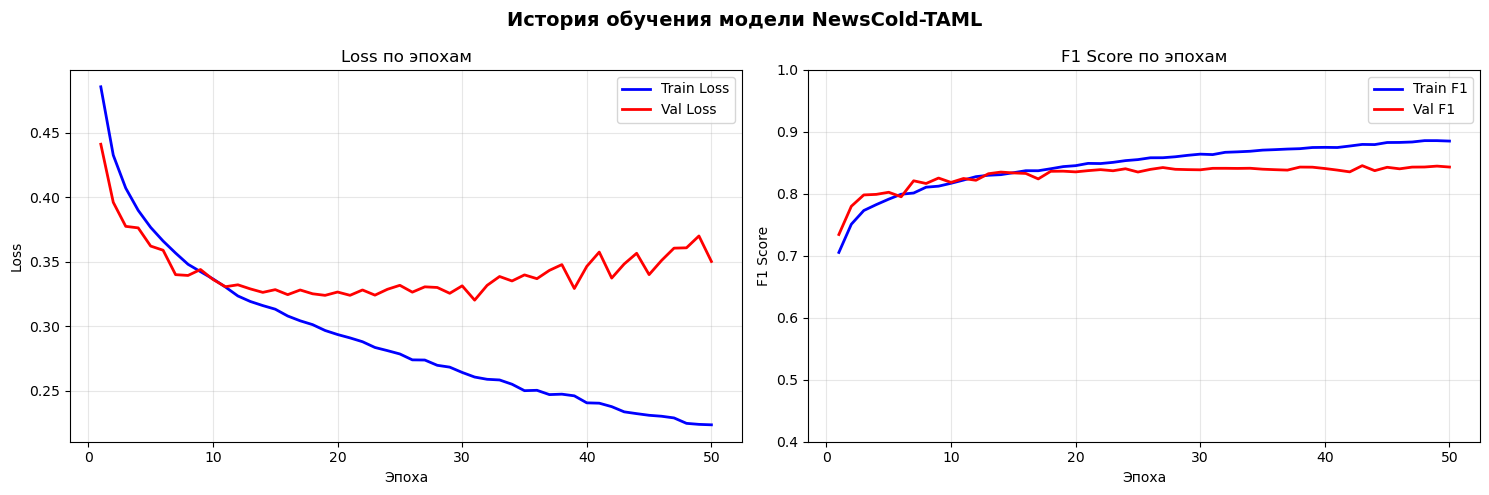

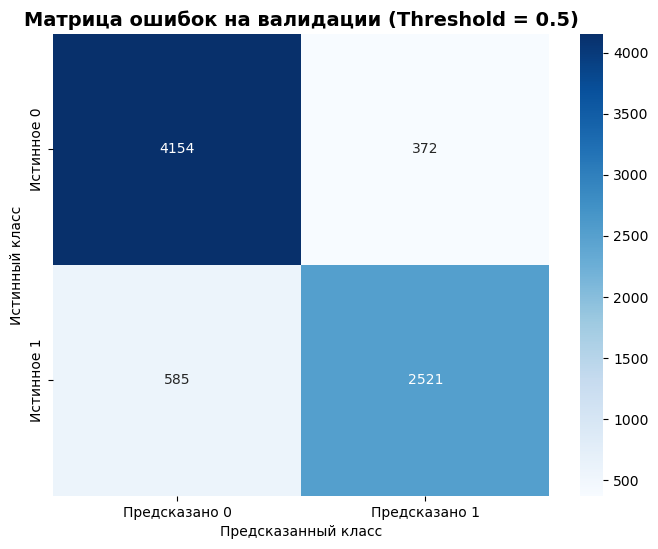


Метрики на валидации (лучшая эпоха):
  Accuracy:  0.8746
  Precision: 0.8714
  Recall:    0.8117
  F1-Score:  0.8405

ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET

РЕЗУЛЬТАТЫ НА TEST SET:
------------------------------------------------------------
Всего образцов: 7,632
Overall AUC:     0.9176
Cold news AUC:   0.9205 (образцов: 2,459)
Hot news AUC:    0.8992 (образцов: 5,173)
F1 Score:        0.8245
Positive ratio cold: 18.46%
Positive ratio hot:  50.34%

ПРОВЕРКА ЦЕЛИ ИССЛЕДОВАНИЯ:
----------------------------------------
✓ ЦЕЛЬ ДОСТИГНУТА: AUC для холодных новостей ≥ 0.750
  Фактическое значение: 0.9205

✓ Отчет сохранен: news_cold_training_report_taml_meta_newscold_correct_ratio.json

ИТОГИ ДЛЯ NEWSCOLD
Директория данных: taml_meta_newscold_correct_ratio
Всего задач: 795
Холодные задачи: 265
Горячие задачи: 530
Общее время: 143.6 секунд
Всего образцов: 50,880

КРАТКИЕ ВЫВОДЫ:
1. Эффективность для холодных новостей: AUC = 0.9205
2. Эффективность для горячих новостей: AUC = 0.8992
3. Общая эффективн

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import time
import os
from pathlib import Path
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================================
# 1. АРХИТЕКТУРА ДЛЯ NEWSCOLD
# ============================================================================

class NewsColdModel(nn.Module):
    """Модель для новостного холодного старта"""
    def __init__(self, embedding_dim=250, temporal_dim=5):
        super().__init__()
        
        # Размерности
        news_emb_dim = 128
        temp_dim = 64
        time_emb_dim = 16
        
        total_input_dim = news_emb_dim + temp_dim + time_emb_dim
        
        # 1. Энкодер новостей
        self.news_encoder = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, news_emb_dim),
            nn.LayerNorm(news_emb_dim),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        
        # 2. Энкодер временных признаков
        self.temporal_encoder = nn.Sequential(
            nn.Linear(temporal_dim, 32),
            nn.GELU(),
            nn.Linear(32, temp_dim),
            nn.LayerNorm(temp_dim),
            nn.GELU()
        )
        
        # 3. Временные эмбеддинги
        self.time_embedding = nn.Embedding(8, time_emb_dim)
        
        # 4. Предсказательный модуль
        self.predictor = nn.Sequential(
            nn.Linear(total_input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        
        self.total_input_dim = total_input_dim
        
    def forward(self, news_emb, temporal_feat, time_period):
        # Кодирование новости
        news_repr = self.news_encoder(news_emb)
        
        # Кодирование временных признаков
        temp_repr = self.temporal_encoder(temporal_feat)
        
        # Временные эмбеддинги
        time_emb = self.time_embedding(time_period.squeeze().long())
        
        # Объединение
        combined = torch.cat([news_repr, temp_repr, time_emb], dim=-1)
        
        # Предсказание
        output = self.predictor(combined)
        return torch.sigmoid(output)


# ============================================================================
# 2. ЗАГРУЗКА И ПОДГОТОВКА РЕАЛЬНЫХ ДАННЫХ
# ============================================================================

def load_news_cold_tasks(meta_dir='taml_meta_newscold_correct_ratio'):
    """Загружает мета-задачи для newscold"""
    print("=" * 80)
    print(f"ЗАГРУЗКА МЕТА-ЗАДАЧ ДЛЯ NEWSCOLD: {meta_dir}")
    print("=" * 80)
    
    # Проверяем существование директории
    if not os.path.exists(meta_dir):
        print(f"✗ Директория {meta_dir} не существует!")
        return [], {}
    
    # Загружаем метаданные
    meta_tasks_path = f'{meta_dir}/meta_tasks.json'
    params_path = f'{meta_dir}/parameters.json'
    
    if not os.path.exists(meta_tasks_path):
        print(f"✗ Файл {meta_tasks_path} не найден!")
        return [], {}
    
    with open(meta_tasks_path, 'r') as f:
        meta_tasks_info = json.load(f)
    
    params = {}
    if os.path.exists(params_path):
        with open(params_path, 'r') as f:
            params = json.load(f)
    
    print(f"✓ Загружено мета-задач: {len(meta_tasks_info)}")
    
    # Загружаем все задачи
    all_tasks = []
    tasks_dir = Path(meta_dir) / 'tasks'
    
    if not tasks_dir.exists():
        print(f"✗ Директория {tasks_dir} не существует!")
        return all_tasks, params
    
    for task_info in meta_tasks_info:
        task_id = task_info.get('task_id', 'unknown')
        task_path = tasks_dir / task_id / 'data.npz'
        
        if task_path.exists():
            try:
                data = np.load(task_path, allow_pickle=True)
                
                # Базовые обязательные поля
                task_data = {
                    'task_id': task_id,
                    'time_period': task_info.get('time_period', 0),
                    'news_group': task_info.get('news_group', 'unknown'),
                    
                    # Support set
                    'support_emb': data['support_embeddings'],
                    'support_labels': data['support_labels'],
                    'support_ids': data['support_news_ids'],
                    
                    # Query set
                    'query_emb': data['query_embeddings'],
                    'query_labels': data['query_labels'],
                    'query_ids': data['query_news_ids'],
                }
                
                # Опциональные поля
                task_data['positive_ratio'] = task_info.get('positive_ratio', 
                                                          task_info.get('positive_ratio_support', 0.5))
                task_data['avg_news_age'] = task_info.get('avg_news_age', 
                                                         task_info.get('avg_news_age_support', 24.0))
                
                all_tasks.append(task_data)
                
            except Exception as e:
                print(f"✗ Ошибка загрузки задачи {task_id}: {e}")
    
    print(f"✓ Успешно загружено: {len(all_tasks)} задач")
    
    # Статистика по группам
    if all_tasks:
        cold_count = sum(1 for t in all_tasks if t['news_group'] == 'cold')
        hot_count = sum(1 for t in all_tasks if t['news_group'] == 'hot')
        print(f"✓ Холодные задачи: {cold_count}, Горячие задачи: {hot_count}")
        print(f"✓ Отношение холодные/горячие: {cold_count/hot_count:.2f}" if hot_count > 0 else "")
    
    return all_tasks, params


def extract_news_cold_features(all_tasks):
    """Извлекает признаки для newscold"""
    print("\n[1/4] ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ДЛЯ NEWSCOLD...")
    
    if not all_tasks:
        print("✗ Нет задач для обработки!")
        return {}
    
    # Собираем ВСЕ данные
    all_samples = {
        'embeddings': [],
        'labels': [],
        'news_ids': [],
        'periods': [],
        'groups': [],  # 1 для cold, 0 для hot
        'news_ages': []
    }
    
    total_samples = 0
    
    for task_data in all_tasks:
        is_cold = 1 if task_data['news_group'] == 'cold' else 0
        period = task_data['time_period']
        task_avg_age = task_data.get('avg_news_age', 24.0)
        
        # Добавляем support set
        n_support = len(task_data['support_emb'])
        if n_support > 0:
            all_samples['embeddings'].append(task_data['support_emb'])
            all_samples['labels'].append(task_data['support_labels'])
            all_samples['news_ids'].append(task_data['support_ids'])
            all_samples['periods'].append(np.full(n_support, period))
            all_samples['groups'].append(np.full(n_support, is_cold))
            
            # Возраст новости на основе avg_news_age с небольшим шумом
            ages = np.full(n_support, task_avg_age) * np.random.uniform(0.8, 1.2, n_support)
            all_samples['news_ages'].append(ages)
            
            total_samples += n_support
        
        # Добавляем query set
        n_query = len(task_data['query_emb'])
        if n_query > 0:
            all_samples['embeddings'].append(task_data['query_emb'])
            all_samples['labels'].append(task_data['query_labels'])
            all_samples['news_ids'].append(task_data['query_ids'])
            all_samples['periods'].append(np.full(n_query, period))
            all_samples['groups'].append(np.full(n_query, is_cold))
            
            ages_query = np.full(n_query, task_avg_age) * np.random.uniform(0.8, 1.2, n_query)
            all_samples['news_ages'].append(ages_query)
            
            total_samples += n_query
    
    # Объединяем все массивы
    for key in all_samples:
        if all_samples[key]:
            all_samples[key] = np.concatenate(all_samples[key])
        else:
            all_samples[key] = np.array([])
    
    print(f"✓ Всего образцов: {total_samples:,}")
    if total_samples > 0:
        print(f"✓ Размер эмбеддингов: {all_samples['embeddings'].shape}")
        print(f"✓ Распределение классов: {all_samples['labels'].mean():.2%} positive")
        print(f"✓ Холодные новости: {all_samples['groups'].mean():.2%}")
    else:
        print("✗ Нет данных для обработки!")
        return {}
    
    # Создаем временные признаки
    print("\n[2/4] СОЗДАНИЕ ВРЕМЕННЫХ ПРИЗНАКОВ...")
    
    n_samples = len(all_samples['embeddings'])
    temporal_features = np.zeros((n_samples, 5), dtype=np.float32)
    
    for i in range(n_samples):
        news_age = all_samples['news_ages'][i]
        is_cold = all_samples['groups'][i]
        period = all_samples['periods'][i]
        
        # 1. Возраст новости (нормализованный 0-1, макс 72 часа)
        age_normalized = max(0, min(1, news_age / 72.0))
        temporal_features[i, 0] = age_normalized
        
        # 2. Временной период (циклическое кодирование)
        hour = period * 3  # каждый период = 3 часа
        temporal_features[i, 1] = np.sin(2 * np.pi * hour / 24)
        temporal_features[i, 2] = np.cos(2 * np.pi * hour / 24)
        
        # 3. Свежесть (экспоненциальный спад)
        temporal_features[i, 3] = np.exp(-age_normalized * 3)
        
        # 4. Индикатор холодной новости
        temporal_features[i, 4] = float(is_cold)
    
    return {
        'embeddings': all_samples['embeddings'],
        'labels': all_samples['labels'],
        'temporal_features': temporal_features,
        'periods': all_samples['periods'],
        'groups': all_samples['groups'],
        'news_ids': all_samples['news_ids']
    }


def create_data_splits(full_data, train_ratio=0.7, val_ratio=0.15):
    """Создание разделений данных"""
    print("\n[3/4] СОЗДАНИЕ РАЗДЕЛЕНИЙ ДАННЫХ...")
    
    if not full_data or len(full_data['embeddings']) == 0:
        print("✗ Нет данных для разделения!")
        return {}, {}, {}
    
    n_samples = len(full_data['embeddings'])
    indices = np.random.permutation(n_samples)
    
    n_train = int(train_ratio * n_samples)
    n_val = int(val_ratio * n_samples)
    
    train_indices = indices[:n_train]
    val_indices = indices[n_train:n_train+n_val]
    test_indices = indices[n_train+n_val:]
    
    splits = {}
    
    for split_name, split_indices in [('train', train_indices), 
                                     ('val', val_indices), 
                                     ('test', test_indices)]:
        
        splits[split_name] = {
            'embeddings': full_data['embeddings'][split_indices],
            'labels': full_data['labels'][split_indices],
            'temporal_features': full_data['temporal_features'][split_indices],
            'periods': full_data['periods'][split_indices],
            'groups': full_data['groups'][split_indices],
        }
        
        split_data = splits[split_name]
        cold_mask = split_data['groups'] == 1
        hot_mask = split_data['groups'] == 0
        
        print(f"✓ {split_name}: {len(split_indices):,} образцов ({len(split_indices)/n_samples:.1%})")
        if np.sum(cold_mask) > 0:
            print(f"  Холодные: {np.sum(cold_mask):,} ({np.sum(cold_mask)/len(split_indices):.1%}), "
                  f"positive: {split_data['labels'][cold_mask].mean():.2%}")
        if np.sum(hot_mask) > 0:
            print(f"  Горячие: {np.sum(hot_mask):,} ({np.sum(hot_mask)/len(split_indices):.1%}), "
                  f"positive: {split_data['labels'][hot_mask].mean():.2%}")
    
    return splits['train'], splits['val'], splits['test']


# ============================================================================
# 3. ОБУЧЕНИЕ МОДЕЛИ С ФУНКЦИЯМИ ВИЗУАЛИЗАЦИИ
# ============================================================================

def calculate_f1_score(predictions, labels, threshold=0.5):
    """Вычисление F1 Score"""
    binary_preds = (predictions >= threshold).astype(int)
    if len(np.unique(labels)) < 2 or len(np.unique(binary_preds)) < 2:
        return 0.5
    return f1_score(labels, binary_preds)


def train_news_cold_model(train_data, val_data, test_data, 
                         embedding_dim=250, epochs=50, batch_size=32):
    """Обучение модели для newscold с сохранением метрик"""
    print("\n[4/4] ОБУЧЕНИЕ МОДЕЛИ ДЛЯ NEWSCOLD...")
    
    # Проверяем данные
    if not train_data or len(train_data['embeddings']) == 0:
        print("✗ Нет данных для обучения!")
        return None, {}
    
    # Создаем модель
    model = NewsColdModel(
        embedding_dim=embedding_dim,
        temporal_dim=5
    )
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Оптимизатор
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    criterion = nn.BCELoss()
    
    print(f"✓ Устройство: {device}")
    print(f"✓ Параметры модели: {sum(p.numel() for p in model.parameters()):,}")
    print(f"✓ Batch size: {batch_size}, Epochs: {epochs}")
    print(f"✓ Обучение на {len(train_data['labels']):,} образцах")
    
    # Метрики
    history = {
        'train_loss': [], 'train_auc': [], 'train_f1': [],
        'val_loss': [], 'val_auc': [], 'val_f1': [],
        'val_auc_cold': [], 'val_auc_hot': []
    }
    
    best_val_auc = 0
    best_model_state = None
    best_val_predictions = None
    best_val_labels = None
    
    print("\n" + "=" * 80)
    print("НАЧАЛО ОБУЧЕНИЯ")
    print("=" * 80)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []
        
        # Обучение
        n_batches = int(np.ceil(len(train_data['labels']) / batch_size))
        indices = np.random.permutation(len(train_data['labels']))
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, len(train_data['labels']))
            batch_indices = indices[start_idx:end_idx]
            
            # Подготавливаем батч
            batch_emb = torch.FloatTensor(train_data['embeddings'][batch_indices]).to(device)
            batch_temp = torch.FloatTensor(train_data['temporal_features'][batch_indices]).to(device)
            batch_time = torch.LongTensor(train_data['periods'][batch_indices]).to(device)
            batch_labels = torch.FloatTensor(train_data['labels'][batch_indices]).reshape(-1, 1).to(device)
            
            # Прямой проход
            preds = model(batch_emb, batch_temp, batch_time)
            loss = criterion(preds, batch_labels)
            
            # Обратный проход
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            # Собираем метрики
            train_loss += loss.item()
            train_preds.extend(preds.detach().cpu().numpy().flatten())
            train_labels.extend(batch_labels.cpu().numpy().flatten())
        
        avg_train_loss = train_loss / n_batches
        
        # Валидация
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []
        val_groups = []
        
        with torch.no_grad():
            n_val_batches = int(np.ceil(len(val_data['labels']) / batch_size))
            
            for batch_idx in range(n_val_batches):
                start_idx = batch_idx * batch_size
                end_idx = min((batch_idx + 1) * batch_size, len(val_data['labels']))
                
                batch_emb = torch.FloatTensor(val_data['embeddings'][start_idx:end_idx]).to(device)
                batch_temp = torch.FloatTensor(val_data['temporal_features'][start_idx:end_idx]).to(device)
                batch_time = torch.LongTensor(val_data['periods'][start_idx:end_idx]).to(device)
                batch_labels = torch.FloatTensor(val_data['labels'][start_idx:end_idx]).reshape(-1, 1).to(device)
                batch_groups = val_data['groups'][start_idx:end_idx]
                
                preds = model(batch_emb, batch_temp, batch_time)
                loss = criterion(preds, batch_labels)
                
                val_loss += loss.item()
                val_preds.extend(preds.cpu().numpy().flatten())
                val_labels.extend(batch_labels.cpu().numpy().flatten())
                val_groups.extend(batch_groups)
        
        avg_val_loss = val_loss / n_val_batches
        
        # Вычисление метрик
        train_preds_flat = np.array(train_preds).flatten()
        train_labels_flat = np.array(train_labels).flatten()
        val_preds_flat = np.array(val_preds).flatten()
        val_labels_flat = np.array(val_labels).flatten()
        val_groups_flat = np.array(val_groups)
        
        train_auc = 0.5
        if len(np.unique(train_labels_flat)) > 1:
            try:
                train_auc = roc_auc_score(train_labels_flat, train_preds_flat)
            except:
                train_auc = 0.5
        
        val_auc = 0.5
        if len(np.unique(val_labels_flat)) > 1:
            try:
                val_auc = roc_auc_score(val_labels_flat, val_preds_flat)
            except:
                val_auc = 0.5
        
        # F1 Score
        train_f1 = calculate_f1_score(train_preds_flat, train_labels_flat)
        val_f1 = calculate_f1_score(val_preds_flat, val_labels_flat)
        
        # AUC отдельно для холодных и горячих новостей
        cold_mask = val_groups_flat == 1
        hot_mask = val_groups_flat == 0
        
        val_auc_cold = 0.5
        if np.sum(cold_mask) > 0 and len(np.unique(val_labels_flat[cold_mask])) > 1:
            try:
                val_auc_cold = roc_auc_score(val_labels_flat[cold_mask], val_preds_flat[cold_mask])
            except:
                val_auc_cold = 0.5
        
        val_auc_hot = 0.5
        if np.sum(hot_mask) > 0 and len(np.unique(val_labels_flat[hot_mask])) > 1:
            try:
                val_auc_hot = roc_auc_score(val_labels_flat[hot_mask], val_preds_flat[hot_mask])
            except:
                val_auc_hot = 0.5
        
        # Сохраняем метрики
        history['train_loss'].append(avg_train_loss)
        history['train_auc'].append(train_auc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(avg_val_loss)
        history['val_auc'].append(val_auc)
        history['val_f1'].append(val_f1)
        history['val_auc_cold'].append(val_auc_cold)
        history['val_auc_hot'].append(val_auc_hot)
        
        # Сохраняем лучшую модель
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_state = model.state_dict().copy()
            best_val_predictions = val_preds_flat.copy()
            best_val_labels = val_labels_flat.copy()
        
        # Логирование
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f}, AUC: {train_auc:.4f}, F1: {train_f1:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f}, AUC: {val_auc:.4f}, F1: {val_f1:.4f}")
    
    # Загружаем лучшую модель
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    print("\n" + "=" * 80)
    print("ОБУЧЕНИЕ ЗАВЕРШЕНО")
    print("=" * 80)
    print(f"✓ Лучшая Val AUC: {best_val_auc:.4f}")
    print(f"✓ Лучшая Val F1: {calculate_f1_score(best_val_predictions, best_val_labels):.4f}")
    
    return model, history, best_val_predictions, best_val_labels


def plot_training_history(history, save_path='training_history.png'):
    """Визуализация истории обучения"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle('История обучения модели NewsCold-TAML', fontsize=14, fontweight='bold')
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # 1. Loss по эпохам
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss по эпохам')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. F1 Score по эпохам
    axes[1].plot(epochs, history['train_f1'], 'b-', label='Train F1', linewidth=2)
    axes[1].plot(epochs, history['val_f1'], 'r-', label='Val F1', linewidth=2)
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('F1 Score по эпохам')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0.4, 1.0])
    
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(val_predictions, val_labels, threshold=0.5, save_path='confusion_matrix.png'):
    """Построение матрицы ошибок на валидации"""
    # Бинаризация предсказаний
    binary_preds = (val_predictions >= threshold).astype(int)
    
    # Вычисление матрицы ошибок
    cm = confusion_matrix(val_labels, binary_preds)
    
    # Создание фигуры
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Визуализация матрицы ошибок
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Предсказано 0', 'Предсказано 1'],
                yticklabels=['Истинное 0', 'Истинное 1'],
                ax=ax)
    
    ax.set_title(f'Матрица ошибок на валидации (Threshold = {threshold})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
    
    # Добавляем метрики
    accuracy = np.trace(cm) / np.sum(cm)
    precision = cm[1, 1] / (cm[1, 1] + cm[0, 1]) if (cm[1, 1] + cm[0, 1]) > 0 else 0
    recall = cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    plt.show()
    
    return {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }


# ============================================================================
# 4. ОЦЕНКА И ОТЧЕТ
# ============================================================================

def evaluate_news_cold_model(model, test_data, batch_size=32):
    """Финальная оценка модели для newscold"""
    print("\n" + "=" * 80)
    print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET")
    print("=" * 80)
    
    if not model or not test_data or len(test_data['labels']) == 0:
        print("✗ Нет модели или данных для оценки!")
        return {
            'overall_auc': 0.5,
            'cold_auc': 0.5,
            'hot_auc': 0.5,
            'test_samples': 0,
            'cold_samples': 0,
            'hot_samples': 0,
            'goal_achieved': False
        }
    
    device = next(model.parameters()).device
    model.eval()
    
    test_preds = []
    test_labels = []
    test_groups = []
    
    with torch.no_grad():
        n_batches = int(np.ceil(len(test_data['labels']) / batch_size))
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, len(test_data['labels']))
            
            batch_emb = torch.FloatTensor(test_data['embeddings'][start_idx:end_idx]).to(device)
            batch_temp = torch.FloatTensor(test_data['temporal_features'][start_idx:end_idx]).to(device)
            batch_time = torch.LongTensor(test_data['periods'][start_idx:end_idx]).to(device)
            batch_labels = test_data['labels'][start_idx:end_idx]
            batch_groups = test_data['groups'][start_idx:end_idx]
            
            preds = model(batch_emb, batch_temp, batch_time)
            
            test_preds.extend(preds.cpu().numpy().flatten())
            test_labels.extend(batch_labels)
            test_groups.extend(batch_groups)
    
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)
    test_groups = np.array(test_groups)
    
    # Общие метрики
    overall_auc = 0.5
    if len(np.unique(test_labels)) > 1:
        try:
            overall_auc = roc_auc_score(test_labels, test_preds)
        except:
            overall_auc = 0.5
    
    # По группам
    cold_mask = test_groups == 1
    hot_mask = test_groups == 0
    
    cold_auc = 0.5
    if np.sum(cold_mask) > 0 and len(np.unique(test_labels[cold_mask])) > 1:
        try:
            cold_auc = roc_auc_score(test_labels[cold_mask], test_preds[cold_mask])
        except:
            cold_auc = 0.5
    
    hot_auc = 0.5
    if np.sum(hot_mask) > 0 and len(np.unique(test_labels[hot_mask])) > 1:
        try:
            hot_auc = roc_auc_score(test_labels[hot_mask], test_preds[hot_mask])
        except:
            hot_auc = 0.5
    
    print(f"\nРЕЗУЛЬТАТЫ НА TEST SET:")
    print("-" * 60)
    print(f"Всего образцов: {len(test_labels):,}")
    print(f"Overall AUC:     {overall_auc:.4f}")
    print(f"Cold news AUC:   {cold_auc:.4f} (образцов: {np.sum(cold_mask):,})")
    print(f"Hot news AUC:    {hot_auc:.4f} (образцов: {np.sum(hot_mask):,})")
    print(f"F1 Score:        {calculate_f1_score(test_preds, test_labels):.4f}")
    
    if np.sum(cold_mask) > 0:
        print(f"Positive ratio cold: {test_labels[cold_mask].mean():.2%}")
    
    if np.sum(hot_mask) > 0:
        print(f"Positive ratio hot:  {test_labels[hot_mask].mean():.2%}")
    
    # Проверка цели
    print(f"\nПРОВЕРКА ЦЕЛИ ИССЛЕДОВАНИЯ:")
    print("-" * 40)
    
    goal_achieved = cold_auc >= 0.750  # Цель: AUC для холодных новостей ≥ 0.750
    
    if goal_achieved:
        print(f"✓ ЦЕЛЬ ДОСТИГНУТА: AUC для холодных новостей ≥ 0.750")
        print(f"  Фактическое значение: {cold_auc:.4f}")
    else:
        print(f"✗ ЦЕЛЬ НЕ ДОСТИГНУТА: AUC для холодных новостей = {cold_auc:.4f} < 0.750")
    
    return {
        'overall_auc': overall_auc,
        'cold_auc': cold_auc,
        'hot_auc': hot_auc,
        'test_samples': len(test_labels),
        'cold_samples': int(np.sum(cold_mask)),
        'hot_samples': int(np.sum(hot_mask)),
        'goal_achieved': bool(goal_achieved),
        'predictions': test_preds,
        'labels': test_labels,
        'groups': test_groups
    }


def save_news_cold_report(model, results, history, meta_tasks_info, filename='news_cold_training_report.json'):
    """Сохранение финального отчета"""
    report = {
        'timestamp': time.strftime("%Y-%m-%d %H:%M:%S"),
        'model': 'NewsColdModel (Только новостной холодный старт)',
        'dataset_info': {
            'total_tasks': len(meta_tasks_info),
            'cold_tasks': sum(1 for t in meta_tasks_info if t.get('news_group') == 'cold'),
            'hot_tasks': sum(1 for t in meta_tasks_info if t.get('news_group') == 'hot'),
            'embedding_dim': meta_tasks_info[0]['support_emb'].shape[1] if meta_tasks_info else 0
        },
        'architecture': {
            'total_parameters': sum(p.numel() for p in model.parameters()),
            'input_dimensions': model.total_input_dim if hasattr(model, 'total_input_dim') else 'N/A'
        },
        'results': {
            'test_overall_auc': float(results['overall_auc']),
            'test_cold_auc': float(results['cold_auc']),
            'test_hot_auc': float(results['hot_auc']),
            'test_samples': results['test_samples'],
            'difference_cold_hot': float(abs(results['cold_auc'] - results['hot_auc']))
        },
        'goal_achieved': results['goal_achieved'],
        'training_history': {
            'final_train_auc': float(history['train_auc'][-1]) if history['train_auc'] else 0.5,
            'final_val_auc': float(history['val_auc'][-1]) if history['val_auc'] else 0.5,
            'best_val_auc': float(max(history['val_auc'])) if history['val_auc'] else 0.5,
            'final_train_f1': float(history['train_f1'][-1]) if history['train_f1'] else 0.5,
            'final_val_f1': float(history['val_f1'][-1]) if history['val_f1'] else 0.5,
            'best_val_f1': float(max(history['val_f1'])) if history['val_f1'] else 0.5
        }
    }
    
    with open(filename, 'w') as f:
        json.dump(report, f, indent=2, ensure_ascii=False)
    
    print(f"\n✓ Отчет сохранен: {filename}")
    
    return report


# ============================================================================
# 5. ОСНОВНОЙ ПАЙПЛАЙН С ГРАФИКАМИ
# ============================================================================

def main_news_cold_with_plots(data_dir=None):
    """Основной пайплайн для новостного холодного старта с графиками"""
    print("=" * 80)
    print("МОДЕЛЬ ДЛЯ НОВОСТНОГО ХОЛОДНОГО СТАРТА (NEWSCOLD) С ГРАФИКАМИ")
    print("=" * 80)
    
    start_time = time.time()
    
    # Определяем директорию с данными
    if data_dir is None:
        # Автоматически выбираем первую доступную директорию
        available_dirs = []
        for dir_name in ['taml_meta_newscold_correct_ratio', 
                        'taml_meta_newscold_smart',
                        'taml_meta_newscold_adaptive']:
            if os.path.exists(dir_name):
                available_dirs.append(dir_name)
        
        if not available_dirs:
            print("✗ Ошибка: Не найдено ни одной директории с данными!")
            print("  Сначала создайте мета-задачи для newscold")
            return None, None, None
        
        data_dir = available_dirs[0]
        print(f"✓ Автоматически выбрана директория: {data_dir}")
    
    # 1. Загрузка мета-задач
    all_tasks, params = load_news_cold_tasks(data_dir)
    
    if not all_tasks:
        print(f"✗ Не удалось загрузить задачи из {data_dir}!")
        return None, None, data_dir
    
    # 2. Извлечение признаков
    full_data = extract_news_cold_features(all_tasks)
    
    if not full_data:
        print(f"✗ Не удалось извлечь признаки из данных!")
        return None, None, data_dir
    
    # 3. Создание разделений
    train_data, val_data, test_data = create_data_splits(full_data)
    
    if not train_data or len(train_data['labels']) == 0:
        print(f"✗ Нет данных для обучения!")
        return None, None, data_dir
    
    # 4. Обучение модели
    embedding_dim = all_tasks[0]['support_emb'].shape[1]
    model, history, val_predictions, val_labels = train_news_cold_model(
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        embedding_dim=embedding_dim,
        epochs=50,
        batch_size=32
    )
    
    if model is None:
        print(f"✗ Обучение не удалось!")
        return None, None, data_dir
    
    # 5. Построение графиков
    print("\n" + "=" * 80)
    print("ПОСТРОЕНИЕ ГРАФИКОВ")
    print("=" * 80)
    
    # График 1: Loss по эпохам и F1 Score
    plot_training_history(history, save_path=f'training_history_{Path(data_dir).name}.png')
    
    # График 2: Матрица ошибок на валидации
    cm_metrics = plot_confusion_matrix(val_predictions, val_labels, 
                                      threshold=0.5, 
                                      save_path=f'confusion_matrix_{Path(data_dir).name}.png')
    
    print(f"\nМетрики на валидации (лучшая эпоха):")
    print(f"  Accuracy:  {cm_metrics['accuracy']:.4f}")
    print(f"  Precision: {cm_metrics['precision']:.4f}")
    print(f"  Recall:    {cm_metrics['recall']:.4f}")
    print(f"  F1-Score:  {cm_metrics['f1_score']:.4f}")
    
    # 6. Финальная оценка
    results = evaluate_news_cold_model(model, test_data)
    
    # 7. Сохранение отчета
    report_filename = f'news_cold_training_report_{Path(data_dir).name}.json'
    model_filename = f'news_cold_model_{Path(data_dir).name}.pth'
    
    report = save_news_cold_report(model, results, history, all_tasks, report_filename)
    
    # 8. Итоги
    total_time = time.time() - start_time
    
    print("\n" + "=" * 80)
    print("ИТОГИ ДЛЯ NEWSCOLD")
    print("=" * 80)
    print(f"Директория данных: {data_dir}")
    print(f"Всего задач: {len(all_tasks)}")
    print(f"Холодные задачи: {sum(1 for t in all_tasks if t.get('news_group') == 'cold')}")
    print(f"Горячие задачи: {sum(1 for t in all_tasks if t.get('news_group') == 'hot')}")
    print(f"Общее время: {total_time:.1f} секунд")
    print(f"Всего образцов: {len(full_data['embeddings']):,}")
    
    print("\n" + "=" * 80)
    print("КРАТКИЕ ВЫВОДЫ:")
    print("=" * 80)
    print(f"1. Эффективность для холодных новостей: AUC = {results['cold_auc']:.4f}")
    print(f"2. Эффективность для горячих новостей: AUC = {results['hot_auc']:.4f}")
    print(f"3. Общая эффективность: AUC = {results['overall_auc']:.4f}")
    print(f"4. F1 Score на валидации: {cm_metrics['f1_score']:.4f}")
    print(f"5. Разница в эффективности: {abs(results['cold_auc'] - results['hot_auc']):.4f}")
    
    if results['goal_achieved']:
        print("6. ✓ Цель по новостному холодному старту ДОСТИГНУТА (AUC ≥ 0.750)")
    else:
        print(f"6. ✗ Цель по новостному холодному старту НЕ достигнута (AUC = {results['cold_auc']:.4f} < 0.750)")
    
    # Сохранение модели
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_config': {
            'embedding_dim': embedding_dim,
            'temporal_dim': 5
        },
        'results': results,
        'history': history,
        'val_predictions': val_predictions,
        'val_labels': val_labels,
        'data_source': data_dir,
        'total_tasks': len(all_tasks),
        'training_date': time.strftime("%Y-%m-%d %H:%M:%S")
    }, model_filename)
    
    print(f"\n✓ Модель сохранена: {model_filename}")
    print(f"✓ Графики сохранены:")
    print(f"  - training_history_{Path(data_dir).name}.png")
    print(f"  - confusion_matrix_{Path(data_dir).name}.png")
    print(f"✓ Отчет сохранен: {report_filename}")
    
    return model, results, data_dir, history, val_predictions, val_labels


# ============================================================================
# ЗАПУСК
# ============================================================================

if __name__ == "__main__":
    print("=" * 80)
    print("МОДЕЛЬ ДЛЯ НОВОСТНОГО ХОЛОДНОГО СТАРТА С ГРАФИКАМИ")
    print("=" * 80)
    print("Доступные директории с данными:")
    
    # Проверяем доступные директории
    available_dirs = []
    for dir_name in ['taml_meta_newscold_correct_ratio', 
                    'taml_meta_newscold_smart',
                    'taml_meta_newscold_adaptive']:
        if os.path.exists(dir_name):
            available_dirs.append(dir_name)
            print(f"  ✓ {dir_name}")
    
    if not available_dirs:
        print("  ✗ Нет доступных директорий!")
        print("\nСначала создайте мета-задачи командой:")
        print("  meta_tasks = create_taml_meta_tasks_newscold_correct_ratio(...)")
    else:
        print(f"\nЗапускаем с директорией: {available_dirs[0]}")
        model, results, data_dir, history, val_preds, val_labels = main_news_cold_with_plots(available_dirs[0])